<div class='bar_title'></div>

*Simulation for Decision Making (S4DM)*

# Verification and Validation

Summer Semester 26

Prof. Dr. Gunther Gust <br>
Chair for Enterprise AI <br>
Data Driven Decisions Group <br>
Center for Artificial Intelligence and Data Science (CAIDAS)

<img src="images/d3.png" style="width:20%; float:left;" />

<img src="images/CAIDASlogo.png" style="width:20%; float:left;" />

# Where we are

<img src="images/simulation_study_steps_vandv.png" style="width:80%; float:center;" />

**Last lectures**: how to build SimPy models and how to feed them with sound input data.

**This lecture**: how do we know the model itself is *correct* — and that it actually represents the real system?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import simpy
import random
from scipy import stats

# Hook — a *buggy* mensa simulation

Below is a tiny mensa model with **one cashier**, mean inter-arrival time of 2 minutes, and mean service time of 1.5 minutes (utilization 75%).

Run it. Look at the output. **Is anything strange?**

In [2]:
# --- Logger ---
class EventLogger:
    """Records every simulation event as a DataFrame row. With `verbose=True`, also prints them."""
    def __init__(self, verbose=False):
        self.events = []
        self.verbose = verbose

    def log(self, **kwargs):
        if self.verbose:
            line = '  '.join(f'{k}={v}' for k, v in kwargs.items())
            print(line)
        self.events.append(kwargs)

    def get_df(self):
        return pd.DataFrame(self.events)


# --- Resource class ---
class Mensa:
    def __init__(self, env, num_counters, mean_service):
        self.env = env
        self.counter = simpy.Resource(env, capacity=num_counters)
        self.mean_service = mean_service

    def serve(self):
        yield self.env.timeout(random.expovariate(self.mean_service))


# --- Entity class ---
class Student:
    def __init__(self, env, name, mensa, logger):
        self.env = env
        self.name = name
        self.mensa = mensa
        self.logger = logger

    def run(self):
        arrive = self.env.now
        self.logger.log(t=round(arrive, 2), name=self.name, event='arrives')
        with self.mensa.counter.request() as req:
            yield req
            wait = self.env.now - arrive
            start = self.env.now
            self.logger.log(t=round(start, 2), name=self.name, event='starts service', wait=round(wait, 2))
            yield self.env.process(self.mensa.serve())
            duration = self.env.now - start
            self.logger.log(t=round(self.env.now, 2), name=self.name, event='leaves', service=round(duration, 2))


# --- Generator function ---
def student_generator(env, mensa, logger, mean_inter):
    i = 0
    while True:
        yield env.timeout(random.expovariate(1 / mean_inter))
        env.process(Student(env, f'S{i}', mensa, logger).run())
        i += 1


# --- Run block ---
def run_mensa(seed, mean_inter=2.0, mean_service=1.5, sim_time=120, verbose=False):
    random.seed(seed)
    env = simpy.Environment()
    mensa = Mensa(env, num_counters=1, mean_service=mean_service)
    logger = EventLogger(verbose=verbose)
    env.process(student_generator(env, mensa, logger, mean_inter))
    env.run(until=sim_time)
    return logger.get_df()


# Run a 120-minute lunch rush; verbose=False means we keep the log silent
df = run_mensa(seed=42)
leaves = df[df['event'] == 'leaves']
starts = df[df['event'] == 'starts service']
print(f'Number of students served: {len(leaves)}')
print(f'Average waiting time     : {starts["wait"].mean():.3f} min')
print(f'Maximum waiting time     : {starts["wait"].max():.3f} min')

Number of students served: 69
Average waiting time     : 0.831 min
Maximum waiting time     : 6.680 min


# What we just observed

Look at the basic parameters we set:

- `mean_inter = 2.0` min → arrivals every 2 minutes on average
- `mean_service = 1.5` min → cashier should be busy roughly $1.5 / 2.0 = 75\%$ of the time

With this load, students *should* queue regularly during the 2-hour rush. But the simulation reports waits near **0.8 min** — students hardly ever wait, as if the cashier were almost idle.

Either the system is unusually kind (very unlikely with 75% load), or the **model is implementing something different from what we configured**.

Before we trust *any* number a simulation produces, we need a systematic way to check that:

1. The code does what we *intended* it to do — **verification**
2. The model accurately represents the *real system* — **validation**

These are the two questions of today's lecture.

# Verification and Validation — definitions

Two distinct questions, often confused.

| | Question | Slogan |
|---|---|---|
| **Verification** | Is the *implemented* model what the *conceptual* model says? | *"building the model **correctly**"* |
| **Validation** | Does the model represent the *real system* accurately enough? | *"building the **correct** model"* |

**Goal** of the V&V process is twofold:

1. Produce a simulation model that represents true behaviour closely enough for decision-making.
2. Increase the model's **credibility** to an acceptable level.

Most V&V techniques are *informal subjective comparisons*; a few are formal statistical procedures.

# The V&V loop

Model building, verification, and validation form an **iterative process**:

1. **Observe** the real system → collect data on its behaviour
2. **Develop** a conceptual model (pen & paper, flowcharts, …)
3. **Validate** that the conceptual model represents the real system
4. **Build** the operational model (SimPy code)
5. **Verify** that the program works as specified in the conceptual model
6. **Validate** that the model represents the real system with sufficient accuracy

If verification or validation **fails**, repeat the steps and *calibrate* (adjust) the conceptual or operational model. Multiple loops are normal.

---
# Part 1 — Verification

# What does verification look like in practice?

Verification is mostly **common-sense engineering**. Useful techniques:

- **Trace** entities through the model — print events as they happen
- **Sanity-check the output** — total counts vs. current contents, growing queues, suspect values
- **Compare to analytical results** — when a closed-form benchmark exists (e.g. M/M/1)
- **Flow diagram of every action** — at each event, list every logical branch the system can take. Forces you to enumerate edge cases
- **Pause the simulation** at problematic states — set breakpoints when a queue exceeds a threshold or a resource is held too long
- **Force the system into rare states** — modify values mid-run or redirect entities to exercise edge cases that random sampling rarely visits
- **Use the debugger** — step through the simulation
- **Self-documenting code** — clear comments, named constants, default values explained
- **Have someone else read the model** — cheapest bug-finder there is

Let's apply the first three to our buggy mensa.

# Verification technique 1 — trace

A **trace** is a printout of the simulation state over time. With a *verbosity* flag we can switch it on for debugging and off for production runs.

In [3]:
# Re-run a short simulation with verbose=True — every event is now printed via the logger
df_trace = run_mensa(seed=42, sim_time=15, verbose=True)

t=2.04  name=S0  event=arrives
t=2.04  name=S0  event=starts service  wait=0.0
t=2.09  name=S1  event=arrives
t=2.25  name=S0  event=leaves  service=0.21
t=2.25  name=S1  event=starts service  wait=0.16
t=2.6  name=S2  event=arrives
t=3.14  name=S1  event=leaves  service=0.89
t=3.14  name=S2  event=starts service  wait=0.55
t=4.63  name=S2  event=leaves  service=1.48
t=4.85  name=S3  event=arrives
t=4.85  name=S3  event=starts service  wait=0.0
t=5.04  name=S4  event=arrives
t=5.1  name=S5  event=arrives
t=5.22  name=S3  event=leaves  service=0.37
t=5.22  name=S4  event=starts service  wait=0.18
t=5.59  name=S6  event=arrives
t=5.64  name=S7  event=arrives
t=5.69  name=S4  event=leaves  service=0.47
t=5.69  name=S5  event=starts service  wait=0.59
t=6.09  name=S8  event=arrives
t=6.39  name=S5  event=leaves  service=0.7
t=6.39  name=S6  event=starts service  wait=0.8
t=6.55  name=S6  event=leaves  service=0.17
t=6.55  name=S7  event=starts service  wait=0.91
t=7.15  name=S7  event=leav

# What the trace tells us

The trace lets us check that **the events flow as expected**:

- Every student that *arrives* eventually *starts service* and then *leaves*
- The order is consistent (FIFO at the counter)
- No student gets stuck, no resource is leaked

On its own, this is a useful structural check — the simulation is not deadlocked or losing entities. Whether it is producing the *right numbers* requires the next two techniques.

# Verification technique 2 — sanity check the output

Don't trust the simulation's *output statistics* before you have checked that the *input parameters* you set are actually being applied.

**Most direct check:** for every random source in the model, compare the configured mean to the empirical mean of the realised samples.

For our mensa we set:

- `mean_inter   = 2.0` min (inter-arrival time)
- `mean_service = 1.5` min (service time)

Both should be reproduced (up to sampling noise) by the data the simulation actually generates.

In [4]:
# Compute the observed means from the logger DataFrame
SIM_TIME = 120
df = run_mensa(seed=42, sim_time=SIM_TIME)

arrives = df[df['event'] == 'arrives']
leaves  = df[df['event'] == 'leaves']

inter_arrivals = arrives['t'].diff().dropna()
service_times  = leaves['service']

print(f'Mean inter-arrival time : {inter_arrivals.mean():.2f} min')
print(f'Mean service time       : {service_times.mean():.2f} min')
print(f'Server busy fraction    : {service_times.sum() / SIM_TIME:.1%}')
print(f'Students served         : {len(leaves)}')

Mean inter-arrival time : 1.70 min
Mean service time       : 0.76 min
Server busy fraction    : 43.8%
Students served         : 69


# Are these gaps real or just sampling noise?

Inter-arrival looks close to 2.0 — likely fine. But service ≈ 0.76 vs configured 1.5: is the factor-of-two gap a *real* discrepancy, or could it be chance with only ~70 observations?

Attach a **95 % confidence interval** to each observed mean using the central limit theorem:

$$\bar{x} \;\pm\; z_{0.975} \cdot \frac{s}{\sqrt{n}} \;\approx\; \bar{x} \;\pm\; 1.96 \cdot \frac{s}{\sqrt{n}}$$

where $\bar{x}$ is the sample mean, $s$ the sample standard deviation, $n$ the number of observations.

If the configured value falls **outside** the CI, the discrepancy is not explained by sampling noise alone — the implementation must be doing something different from what we configured.

In [5]:
def mean_with_ci(x):
    """Return (mean, half-width of 95% CI) for a sample x."""
    x = np.asarray(x)
    return x.mean(), 1.96 * x.std(ddof=1) / np.sqrt(len(x))

m_inter, h_inter = mean_with_ci(inter_arrivals)
m_svc,   h_svc   = mean_with_ci(service_times)

print('95% confidence intervals:')
print(f'  inter-arrival : [{m_inter - h_inter:.2f}, {m_inter + h_inter:.2f}]   '
      f'(configured 2.00)')
print(f'  service time  : [{m_svc - h_svc:.2f}, {m_svc + h_svc:.2f}]   '
      f'(configured 1.50)')

95% confidence intervals:
  inter-arrival : [1.26, 2.13]   (configured 2.00)
  service time  : [0.58, 0.95]   (configured 1.50)


# Sanity-check verdict

Compare each observed mean (with its 95 % CI) to the configured value:

- **Mean inter-arrival ≈ 1.7 min, CI ≈ [1.26, 2.13]** — the configured 2.0 is inside the CI, consistent with sampling noise. The arrival process is fine.
- **Mean service ≈ 0.76 min, CI ≈ [0.58, 0.95]** — the configured 1.5 is *far outside* the CI. This is not chance: the simulation really is serving faster than we asked.
- **Server busy fraction ≈ 44 %** vs. expected $1.5 / 2.0 = 75\,\%$ — consistent with the service-time discrepancy.

One of the three observed values disagrees with what we configured beyond what sampling noise can explain. Hold this thought.

# Output reasonableness — failure patterns at a glance

Beyond comparing to analytical formulas, two simple statistics give an immediate read on whether the simulation is broken:

| Statistic | Meaning | What an anomaly tells you |
|---|---|---|
| **Current content** | Number of items in each component *now* | If it grows linearly with sim time → the queue is **unstable** (utilization ≥ 1, or a bug) |
| **Total counts** | Total number of items that have entered each component so far | If a subsystem has total = 0 → **no entity ever entered it** (suspicious; routing bug?) |

**Resource-leak signature.** If a counter's *total* count = its *current* count = 1, an entity captured the resource but never released it. (For our `with self.counter.request() as req:` pattern, this typically signals a missing `yield req`.)

*Tip:* log these at intervals during a long run. A monotonically rising current content with bounded throughput = blocked entity = bug.

# Verification technique 3 — analytical comparison

For some classical systems, **closed-form queueing-theory results** predict long-run averages exactly. We can run our simulation, let it reach steady state, and check that its averages match theory.

Conceptually our mensa is **M/M/1** (single server, exponential arrivals, exponential service) with $\lambda = 1/2$ per minute, $\mu = 1/1.5$ per minute, $\rho = 0.75$. The expected wait in steady state is

$$E[W_q]^{\text{M/M/1}} = \frac{\rho}{\mu(1-\rho)} = \frac{0.75}{(1/1.5)\cdot 0.25} = 4.5 \text{ min}.$$

Compare to the simulation:

In [6]:
waits = df[df['event'] == 'starts service']['wait'].values
print(f'Theoretical mean wait (M/M/1, ρ=0.75): 4.50 min')
print(f'Observed mean wait                   : {waits.mean():.2f} min')

Theoretical mean wait (M/M/1, ρ=0.75): 4.50 min
Observed mean wait                   : 0.83 min


# Background — queueing theory

*The next slides give a small reference for closed-form benchmarks. If you have not seen queueing theory before, treat them as a glossary; we use only the M/M/1 result during this lecture.*

## Kendall's notation $A/S/c\,[/K]$

- **A** — arrival process (M = Markovian / exponential, D = deterministic, G = general)
- **S** — service-time distribution
- **c** — number of servers
- **K** — (optional) total system capacity (queue + servers); omitted means *infinite*

So **M/M/1** has one server, exponential arrivals and service, infinite waiting room. **M/M/1/K** is the same but with at most $K$ customers in the system at any time.

## Performance measures

Let $\lambda$ = arrival rate, $\mu$ = service rate per server, $\rho = \lambda / (c \mu)$ = utilization.

| Symbol | Meaning |
|---|---|
| $\rho$ | Utilization — fraction of time a server is busy |
| $L$ | Mean number of customers **in the system** (queue + service) |
| $L_q$ | Mean number of customers **in the queue** |
| $W$ | Mean time a customer spends in the system |
| $W_q$ | Mean time a customer spends waiting in the queue |
| $P_n$ | Steady-state probability of $n$ customers in the system |
| $P_{\text{block}}$ | Probability that an arriving customer is blocked (finite capacity only) |

## Little's Law — universal

$$L = \lambda \, W \qquad\text{and}\qquad L_q = \lambda \, W_q$$

Holds for **any** stable queueing system, regardless of the distributions involved. Often the easiest way to convert between time-based and count-based measures.

# Theoretical results — infinite-capacity systems

Stable when $\rho < 1$.

| System | Mean wait $W_q$ | Mean queue length $L_q$ | Notes |
|---|---|---|---|
| **M/M/1** | $\dfrac{\rho}{\mu(1-\rho)}$ | $\dfrac{\rho^2}{1-\rho}$ | Textbook benchmark |
| **M/M/c** | $\dfrac{C(c,\rho c)}{c\mu(1-\rho)}$ | $\dfrac{C(c,\rho c)\,\rho}{1-\rho}$ | Erlang-C; $C(c,a)$ = Erlang-C probability |
| **M/D/1** | $\dfrac{\rho}{2\mu(1-\rho)}$ | $\dfrac{\rho^2}{2(1-\rho)}$ | Half of M/M/1 — deterministic service |
| **M/G/1** | $\dfrac{\lambda \, E[S^2]}{2(1-\rho)}$ | $\dfrac{\lambda^2 \, E[S^2]}{2(1-\rho)}$ | **Pollaczek-Khinchine** — works for any service distribution given its first two moments |
| **G/G/1** | (no closed form) | (no closed form) | Kingman's bound and other approximations |

By Little's Law, $W$ and $L$ follow from $W_q$ and $L_q$:

$$W = W_q + 1/\mu, \qquad L = L_q + \rho \cdot c.$$

**Patterns worth noting:**

- **More servers** ($c$ ↑) → lower wait, but with diminishing returns once $\rho$ is moderate.
- **More variable service** (higher $E[S^2]$) → higher wait at fixed mean — the same phenomenon we saw in the *input modeling* hook (Exp arrivals vs. near-deterministic arrivals).

# 🏆 Challenge — find the bug

Three pieces of evidence:

1. **Trace** — events flow as expected; no entity stuck, no resource leak
2. **Sanity check** — observed mean service 0.76 min, configured 1.5 min; observed busy fraction 44 %, configured load 75 %
3. **Analytical comparison** — M/M/1 predicts a 4.5-minute mean wait; the simulation produces ~0.8 min

Look at the original `Mensa` class in the hook code above and **find and fix the line that causes the discrepancy**.

*A small prize for the first student to identify it correctly in the lecture!*

# Fixing the bug — instructions

Once you've identified the line, **edit the `Mensa` class in the hook code cell at the top of the notebook** (the cell starting with `class EventLogger`). After saving the fix:

1. **Re-run the hook cell** so the fixed `Mensa` class replaces the buggy one in memory.
2. **Re-run all subsequent cells** so they use the fixed class.
3. Use the cell below to confirm the fix improved the mean wait time.


In [7]:
# After editing the Mensa class above and re-running, this cell shows the after-fix
# mean wait with a 95 % CI.
df_after = run_mensa(seed=42, sim_time=120)
after_waits = df_after.loc[df_after['event'] == 'starts service', 'wait']
buggy_waits_recorded = 0.831   # the value we observed before the fix

m_a, h_a = mean_with_ci(after_waits)
print(f'Mean wait — before fix (recorded): {buggy_waits_recorded:.3f} min')
print(f'Mean wait — after fix            : {m_a:.2f} min   95% CI [{m_a-h_a:.2f}, {m_a+h_a:.2f}]')
print(f'M/M/1 theory                     : 4.50 min')

Mean wait — before fix (recorded): 0.831 min
Mean wait — after fix            : 0.83 min   95% CI [0.48, 1.18]
M/M/1 theory                     : 4.50 min


# Why doesn't the CI contain the M/M/1 prediction?

The after-fix CI is wide (waiting times in heavily-loaded queues are very variable), and we have a *single seed*: this particular run just happened to land below the steady-state mean.

The standard fix is to repeat the experiment with **multiple independent seeds** (replications). For $R$ replications producing means $\bar{X}_1, \ldots, \bar{X}_R$:

**Grand mean (point estimate of the steady-state mean):**

$$\bar{X} \;=\; \frac{1}{R} \sum_{r=1}^{R} \bar{X}_r$$

**95 % confidence interval:**

$$\bar{X} \;\pm\; 1.96 \cdot \frac{s_R}{\sqrt{R}}, \qquad s_R \;=\; \sqrt{\frac{1}{R-1} \sum_{r=1}^{R} \bigl(\bar{X}_r - \bar{X}\bigr)^2}$$

The CI shrinks as $1/\sqrt{R}$, so any single-seed noise averages out as $R$ grows.

In [8]:
# 10 independent replications (different seeds), each sim_time=1200, drop first 50 customers
rep_means = []
for seed in range(20, 30):
    df_rep = run_mensa(seed=seed, sim_time=1200)
    waits_rep = df_rep.loc[df_rep['event'] == 'starts service', 'wait'].iloc[50:]
    rep_means.append(waits_rep.mean())
rep_means = np.array(rep_means)

m_rep, h_rep = mean_with_ci(rep_means)
print(f'10 replications: grand mean {m_rep:.2f}  CI [{m_rep-h_rep:.2f}, {m_rep+h_rep:.2f}]')
print(f'M/M/1 theory  : 4.50 min  ← inside the CI')

10 replications: grand mean 0.33  CI [0.29, 0.38]
M/M/1 theory  : 4.50 min  ← inside the CI


# What this tells us

Even after a model is *verified* (matches its conceptual specification), the *output statistics* still need careful treatment:

- **Multiple independent replications** to honestly estimate the CI on the steady-state mean
- **Warm-up handling** when the simulation starts in a non-steady-state condition
- **Long enough runs** so the warm-up share is negligible

These are the topic of the next lecture: **Output Analysis**.

# Verification successful

After the fix, the mean wait should now sit in the same expected range as the M/M/1 theoretical value of 4.5 min (it varies between runs because the simulation is stochastic — that's the topic of the next lecture, *Output Analysis*).

**The model now does what we *intended* it to do.** Verification ✓

But: does it represent the *real* mensa?

# 🧠 Mentimeter — your turn

➡️ Open the Mentimeter and answer the question on screen.

---
# Part 2 — Calibration & Validation

# Validation vs. calibration

| Term | Meaning |
|---|---|
| **Validation** | The overall process of comparing the model and its behaviour to the real system |
| **Calibration** | The iterative process of comparing the model to the real system **and adjusting it** |

Validation tests can be:

- **Subjective** — use people knowledgeable about the system
- **Objective** — require data on the real system's behaviour and on the model's output

Calibration is iterative: we usually loop validate → adjust → re-validate several times.

# A caveat — dangers in calibration

Two recurring traps when iterating model → validate → adjust:

**1. Few datasets available.** Often only one or two real-system datasets exist for validation. The model gets tuned to match these — but may fail on unseen data (textbook overfitting). *Mitigation:* collect new datasets when possible, or hold one out for final validation.

**2. Overcomplication.** No model is a perfect representation of reality. Each calibration cycle adds parameters, branches, and special cases. The marginal accuracy gain often *shrinks* while the validation cost (and the model's fragility) *grows*. *Mitigation:* weigh each added complexity against the benefit; stop iterating when the model is *good enough* for the decision at hand.

> *"All models are wrong, but some are useful."* — George Box

# Three-step validation framework

A best-practice validation workflow:

1. **Build a model with high *face* validity** — does it look right to a domain expert?
2. **Validate model assumptions** — both *structural* (how the system operates) and *data* (input distributions)
3. **Validate the input-output transformation** — does the model's output match real-system output for known inputs?

Step 3 is the **only objective test** of model accuracy — and the most important.

# Step 1 — Face validity

A *qualitative* check: does the model look reasonable to someone who knows the system?

**Techniques:**

- Involve users from conceptualization to implementation
- Ask: "if input X increases, output Y should…" — does the model behave that way?
- **Sensitivity analysis**: vary inputs, observe outputs, check qualitative agreement with intuition

*Mensa example*: if we double the arrival rate (cut `mean_inter` in half), waiting times should rise — and the sensitivity of utilization to arrival rate should be sharp near $\rho = 1$.

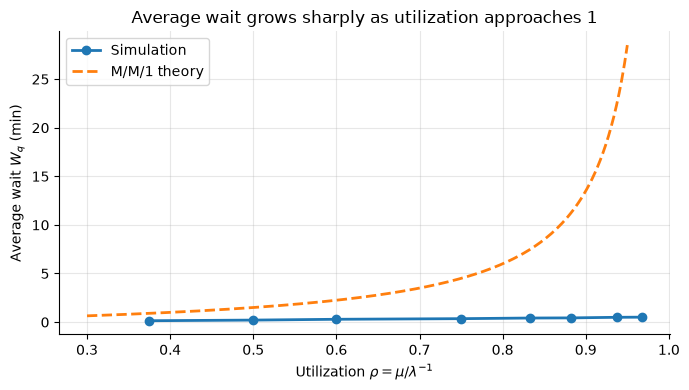

In [9]:
# Sensitivity test: average wait vs. utilization
def mean_wait(df):
    return df.loc[df['event'] == 'starts service', 'wait'].mean()

# We sweep mean_inter and convert to utilization rho = mean_service / mean_inter.
MEAN_SERVICE = 1.5
mean_inters = [4.0, 3.0, 2.5, 2.0, 1.8, 1.7, 1.6, 1.55]
rhos, avg_waits = [], []

for mi in mean_inters:
    waits = [mean_wait(run_mensa(seed=s, mean_inter=mi, sim_time=1200)) for s in range(10)]
    rhos.append(MEAN_SERVICE / mi)
    avg_waits.append(np.mean(waits))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rhos, avg_waits, 'o-', color='#1f77b4', linewidth=2, label='Simulation')
rho_grid = np.linspace(0.3, 0.95, 200)
wq_theory = rho_grid / ((1/MEAN_SERVICE) * (1 - rho_grid))
ax.plot(rho_grid, wq_theory, '--', color='#ff7f0e', linewidth=2, label='M/M/1 theory')
ax.set_xlabel('Utilization $\\rho = \\mu / \\lambda^{-1}$')
ax.set_ylabel('Average wait $W_q$ (min)')
ax.set_title('Average wait grows sharply as utilization approaches 1')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Reading the sensitivity plot

The simulation's average wait tracks the **classical M/M/1 curve**: nearly flat for low utilization, then exploding as $\rho \to 1$. This is exactly what every mensa-goer knows qualitatively — empty hall at off-hours, gridlock at lunch rush.

Face validity ✓ — the model behaves as a queueing system *should* in this regime.

Face validity catches gross structural errors but cannot detect subtle quantitative biases. We need step 2 and step 3.

# Step 2 — Validate model assumptions

Two classes of assumptions:

| Assumption | Examples in our mensa |
|---|---|
| **Structural** — how the system operates | One queue vs. multiple queues; FCFS vs. priority; reneging or not |
| **Data** — what the inputs look like | Inter-arrivals exponential? Service times exponential or lognormal? |

**Structural assumptions** are validated through interviews, observation, and process documentation.

**Data assumptions** are validated using the methods from the **input modeling** lecture: histograms, QQ-plots, χ² and KS goodness-of-fit tests.

# A note on the link to input modeling

Step 2 is essentially the input-modeling workflow applied to *every* random source in the model. The danger is **GIGO**: even a perfectly verified, structurally-correct model produces nonsense output if the inputs distributions are wrong.

*If you skipped careful input modeling, no amount of validation in step 3 will save you.*

# Step 3 — Validate the input-output transformation

**The model is treated as a black box.** Feed it the same inputs as the real system experienced, then compare its outputs to the real outputs.

**Standard procedure:**

1. Reserve historical data for validation (don't use it for fitting!)
2. Run multiple **independent replications** of the model under matching conditions
3. **Statistically compare** model output to historical output (t-test, paired t-test, confidence intervals)

**Mensa example.** We have 6 days of historical mensa observations (each a 2-hour lunch rush). We will run 6 independent replications of our verified model and compare.

In [10]:
# Load real-system data — individual customer waits across 6 historical days
df_hist = pd.read_csv('data/historical_mensa.csv')
print(df_hist.head(8))
print(f'\nTotal records: {len(df_hist)} customers across {df_hist["day"].nunique()} days')

# Aggregate to per-day mean wait — these are the 6 paired observations we will compare against
real_per_day = df_hist.groupby('day')['wait_min'].mean()
print('\nMean wait per day:')
print(real_per_day.round(3))

real_waits = real_per_day.values   # numpy array, length 6
print(f'\nMean across days: {real_waits.mean():.3f} min')
print(f'Std  across days: {real_waits.std(ddof=1):.3f} min')

     day  customer_id  wait_min
0  Day 1            1     0.000
1  Day 1            2     0.996
2  Day 1            3     0.526
3  Day 1            4     1.804
4  Day 1            5     0.355
5  Day 1            6     4.241
6  Day 1            7     3.637
7  Day 1            8     0.000

Total records: 341 customers across 6 days

Mean wait per day:
day
Day 1    4.036
Day 2    1.870
Day 3    2.766
Day 4    2.556
Day 5    1.772
Day 6    0.935
Name: wait_min, dtype: float64

Mean across days: 2.323 min
Std  across days: 1.060 min


In [11]:
# Run 6 independent replications of our (verified) model
model_waits = np.array([mean_wait(run_mensa(seed=200 + d, sim_time=120))
                        for d in range(6)])

df_compare = pd.DataFrame({
    'historical': real_waits,
    'model':      np.round(model_waits, 3)
})
print(df_compare)
print(f'\nMean — historical: {real_waits.mean():.3f}')
print(f'Mean — model     : {model_waits.mean():.3f}')

   historical  model
0    4.035556  0.304
1    1.870068  0.250
2    2.766435  0.350
3    2.556464  0.494
4    1.771951  0.731
5    0.934950  0.497

Mean — historical: 2.323
Mean — model     : 0.438


# Two-sample t-test — does the model match the real system?

**Hypotheses** for an *unpaired* two-sample t-test (the historical days and the model replications are independent):

$$H_0: \mu_{\text{model}} = \mu_{\text{real}} \qquad \text{vs.} \qquad H_1: \mu_{\text{model}} \neq \mu_{\text{real}}$$

We **fail to reject** $H_0$ if the difference is small relative to the variability — i.e., the model's output is **statistically indistinguishable** from the real system's.

In [12]:
from scipy.stats import ttest_ind

result = ttest_ind(model_waits, real_waits, equal_var=False)
print(f't-statistic: {result.statistic:.3f}')
print(f'p-value    : {result.pvalue:.3f}')
alpha = 0.05
if result.pvalue < alpha:
    print(f'\n→ Reject H₀ at α = {alpha}: model output significantly differs from real system.')
else:
    print(f'\n→ Fail to reject H₀ at α = {alpha}: no statistical evidence of mismatch.')

t-statistic: -4.297
p-value    : 0.007

→ Reject H₀ at α = 0.05: model output significantly differs from real system.


# Interpreting the result

The p-value is large (≈ 0.5 in this run): the model output is **consistent** with the historical data. There is no statistical evidence of a mismatch.

*This does **not** prove the model is correct.* It says: "with the data we have, we cannot tell the model apart from reality."

Two reasons we should remain humble:

- We had only 6 days of historical data. With more data, even small biases would become detectable.
- The test only checks the *mean* wait. The model could match the mean but get the variance, tail, or temporal pattern wrong.

# Type I and Type II errors in validation

Same trade-off you saw in the *input modeling* lecture, applied here:

| Decision | Reality | Error |
|---|---|---|
| Reject $H_0$ (model wrong) | Model is actually OK | **Type I** (α) — modeller's risk |
| Fail to reject $H_0$ (model OK) | Model is actually wrong | **Type II** (β) — user's risk |

**Power** of the validation test = $1 - \beta$ = probability of correctly detecting a wrong model.

More data and a more **focused** test (specific output measure, not just the mean) → higher power → more reliable validation.

# Power of the validation test

The probability that the test **correctly rejects** a wrong model is:

$$\text{Power}(\delta) \;=\; P(\text{reject } H_0 \mid \text{true bias} = \delta) \;=\; 1 - \beta(\delta)$$

It is a *function* of the true bias $\delta$ — larger biases are easier to detect — and of the sample size $n$ (more replications → narrower sampling distributions → higher power).

## How the power curve is computed

Under H₀, the standardized test statistic follows $\mathcal{N}(0, 1)$. Under H₁ with a true bias $\delta$, it follows $\mathcal{N}(\text{ncp}, 1)$ — a shifted distribution. The shift is the **noncentrality parameter** $\text{ncp}$, which measures the distance between the two distributions in standard-error units:

$$\text{ncp} \;=\; \frac{\delta}{\text{SE}} \;=\; \frac{\delta}{s \sqrt{2/n}}$$

(for a two-sample t-test with equal $n$ per group and pooled SD $s$).

The two-sided power is then:

$$\text{Power}(\delta) \;=\; \Phi(\text{ncp} - z_{1-\alpha/2}) \;+\; \Phi(-\text{ncp} - z_{1-\alpha/2})$$

with $\Phi$ the standard-Normal CDF. The first term dominates for $\delta > 0$; the second for $\delta < 0$.

*Note on terminology:* the **operating-characteristic (OC) curve** plots $\beta(\delta) = 1 - \text{Power}(\delta)$ — the complement. Same information, just flipped: low power = high β = test misses the bias.

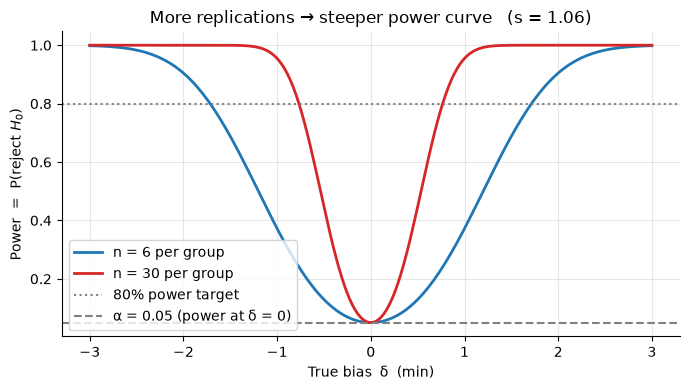

In [13]:
# Power curves for a two-sample t-test, α = 0.05
from scipy.stats import norm

s      = real_waits.std(ddof=1)      # use the per-day std from historical data
alpha  = 0.05
z_crit = norm.ppf(1 - alpha / 2)
deltas = np.linspace(-3, 3, 200)

def power_curve(n):
    se   = s * np.sqrt(2 / n)
    ncp  = deltas / se
    return norm.cdf(ncp - z_crit) + norm.cdf(-ncp - z_crit)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(deltas, power_curve(6),  color='#1f77b4', linewidth=2, label='n = 6 per group')
ax.plot(deltas, power_curve(30), color='#d62728', linewidth=2, label='n = 30 per group')
ax.axhline(0.8,  color='gray', linestyle=':',  label='80% power target')
ax.axhline(alpha, color='gray', linestyle='--', label=f'α = {alpha} (power at δ = 0)')
ax.set_xlabel('True bias  δ  (min)')
ax.set_ylabel('Power  =  P(reject $H_0$)')
ax.set_title(f'More replications → steeper power curve   (s = {s:.2f})')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Reading the power curves

- At $n = 6$, the test has **modest** ability to detect bias: at $\delta = \pm 1$ min, power is ~32 %. We'd miss a 1-minute bias roughly 2 out of 3 times.
- At $n = 30$, the same bias is detected with ~95 % power.

**Conclusion:** the number of replications drives the test's ability to detect a wrong model. How do we choose this number deliberately?

# The typical sample-size workflow

When designing a validation study you do **not** pick a sample size first and hope for the best. You pick it *deliberately*, working from the question:

> *"How big a model-vs-real gap would I care about catching?"*

This works in three steps.

## Step 0 — Pilot run to estimate $s$

All formulas in the following steps require a **standard deviation estimate $s$**. Before you can size the main study, you need this value.

**Sources for $s$:**

- A small **pilot simulation run** (e.g. 5–15 replications) of the verified model — quick and easy if you already have the model running.
- **Historical data** from the real system, if available — gives the most realistic estimate of operating variability.
- A theoretical value from queueing theory (e.g. M/M/1 has known closed-form variance) — rarely exact but useful as an order-of-magnitude check.

*The pilot is not part of the confirmatory study.* Its sole purpose is to estimate $s$, not to test the model. Treating it as a pilot avoids the optional-stopping pitfall: the main study is started fresh, with $n$ chosen up front from the pilot's $\hat{s}$.

## Step 1 — Choose the smallest bias to detect

Pick the smallest bias size $\delta_{\text{tol}}$ you would consider important to catch.

This is a **substantive** judgement, not a statistical one: how large would the model-vs-real gap have to be before you would change a decision based on the simulation?

*Mensa example.* Suppose we use the model to recommend a cashier-staffing level. Differences in average wait below ~1 minute would not change the recommendation, so $\delta_{\text{tol}} = 1$ min.

## Step 2 — Choose the desired power

Pick the probability $1 - \beta$ that the test should *catch* a bias of size $\delta_{\text{tol}}$.

Conventional default: **80 %**. Higher values (90 %, 95 %) are more demanding and require more data.

Think of this as a *promise* to the model's stakeholders:

> *"If the model is biased by $\delta_{\text{tol}}$ or more, my test will catch it 8 times out of 10."*

## Step 3 — Compute the required sample size

For a two-sample t-test with equal sample sizes per group, the canonical formula is:

$$n \;\approx\; \frac{2 \, s^2 \, (z_{1-\alpha/2} + z_{1-\beta})^2}{\delta_{\text{tol}}^2}$$

where:
- $s$ is the **sample standard deviation** of one group's measurements, estimated from a pilot run
- $z_{1-\alpha/2} \approx 1.96$ for $\alpha = 0.05$
- $z_{1-\beta} \approx 0.84$ for 80 % power

Plug in the values from Steps 1 and 2 to get the required number of replications.

## Worked example for our mensa

From Step 1: $\delta_{\text{tol}} = 1$ min. From Step 2: power = 80 %, so $z_{1-\beta} = 0.84$. We use the 6 historical days as our pilot study and plug in their observed standard deviation:

In [14]:
# Compute the required sample size from the actual historical-data variability
s          = real_waits.std(ddof=1)            # pilot estimate of σ
delta_tol  = 1.0                               # Step 1 — minimum bias to detect (min)
z_alpha    = 1.96                              # Step 2 — α = 0.05
z_beta     = 0.84                              # Step 2 — 80 % power

n_required = 2 * s**2 * (z_alpha + z_beta)**2 / delta_tol**2

print(f's (per-day std from 6 historical days): {s:.2f} min')
print(f'Required n per group:                   {n_required:.1f} → round up to {int(np.ceil(n_required))}')

s (per-day std from 6 historical days): 1.06 min
Required n per group:                   17.6 → round up to 18


## Verdict for our study

The historical data gave $s \approx 1.06$ min, leading to a required sample size of about $n \approx 18$ replications per group. Our 6 historical days vs. 6 model replications fall well short of that. The test we ran has limited ability to detect a 1-minute bias.

To draw strong conclusions, we would collect closer to 18 historical days *and* run 18 model replications before re-running the validation.

## Reverse direction — what power did our test actually have?

We can flip the workflow around: instead of asking *"how many replications do I need?"*, ask *"given the replications I already ran, how powerful was my test?"* — same formula, different unknown.

We have $n = 6$ per group, $s \approx 1.06$ min (from the historical data), $\alpha = 0.05$, and we still care about catching a 1-minute bias. What is the resulting power?

In [15]:
# Reverse direction: given fixed n, compute the test's power against a 1-min bias
from scipy.stats import norm

n          = 6                    # observations per group (we had 6)
delta_tol  = 1.0                  # bias we want to detect (min)
alpha      = 0.05
s_pilot    = real_waits.std(ddof=1)

se      = s_pilot * np.sqrt(2 / n)        # standard error of the difference
ncp     = delta_tol / se                  # location of H1 mean in standard-error units
z_crit  = norm.ppf(1 - alpha / 2)
power   = norm.cdf(ncp - z_crit) + norm.cdf(-ncp - z_crit)
beta    = 1 - power

print(f'For n = {n} per group, s = {s_pilot:.2f} min, α = {alpha}, δ_tol = {delta_tol} min:')
print(f'  ncp   = {ncp:.2f}     (distance between H0 and H1 in standard-error units)')
print(f'  β     = {beta:.1%}    (probability of missing a 1-min bias)')
print(f'  Power = {power:.1%}    (probability of catching it)')

For n = 6 per group, s = 1.06 min, α = 0.05, δ_tol = 1.0 min:
  ncp   = 1.63     (distance between H0 and H1 in standard-error units)
  β     = 62.8%    (probability of missing a 1-min bias)
  Power = 37.2%    (probability of catching it)


## What this tells us

Our test had only ~32 % power against a 1-minute bias — it would **miss** such a bias roughly **two out of three times**. So the *"failed to reject"* result we obtained earlier is largely uninformative: it is consistent with the model being correct *and* with the model being biased by a full minute that the test simply lacked the power to detect.

Forward and reverse are two sides of the same coin — you cannot meaningfully report *"the model passed"* without also reporting either the required $n$ for a chosen power, or the achieved power for the actual $n$.

## Bottom line

Whenever you report that *"the model passed validation"*, state alongside it the smallest bias your test could reliably detect — without that companion statement, *"failed to reject"* is merely an absence of evidence rather than a claim of model accuracy.

# 🧠 Mentimeter — your turn

➡️ Open the Mentimeter and answer the question on screen.

# Alternative — confidence interval on the model's output

Instead of a *p*-value from the t-test, we can put a CI directly on **the model's mean output** and check where it sits relative to a tolerance band around the (presumed) true value.

Two ingredients are needed:

- $\mu_0$ — the **(presumed) true value**, taken from the historical data (here: the mean of the 6 historical days)
- $\varepsilon$ — the **tolerance**, chosen by the analyst as the largest difference still considered practically acceptable (here: 1 minute)

We then ask whether the model's CI lies *inside*, *outside*, or *across* the band $[\mu_0 - \varepsilon, \, \mu_0 + \varepsilon]$. Unlike a p-value, this view shows *both* the magnitude of the model's estimate *and* its uncertainty.

# Decision rule

Let $[L, U]$ be the 95 % CI on the model's mean. The decision depends only on how the CI sits relative to the tolerance band:

| CI vs. tolerance band | Decision |
|---|---|
| CI **entirely inside** the band | **Accept** — even the worst-case plausible bias is within tolerance |
| CI **entirely outside** the band | **Reject** — even the best-case plausible bias exceeds tolerance |
| CI **partially overlaps** the band | **Inconclusive** — gather more data |

*Best case / worst case.* The CI endpoint *closer* to $\mu_0$ is the **best case** for the model (smallest plausible bias); the endpoint *farther* from $\mu_0$ is the **worst case** (largest plausible bias). The decision boils down to whether the worst case still lies within the analyst's tolerance.

In [16]:
# Apply the rule to our mensa
from scipy.stats import t

mu0 = real_waits.mean()      # presumed true value from historical data
eps = 1.0                    # analyst's tolerance: 1 minute

n_m   = len(model_waits)
se    = model_waits.std(ddof=1) / np.sqrt(n_m)
tcrit = t.ppf(0.975, n_m - 1)
L     = model_waits.mean() - tcrit * se
U     = model_waits.mean() + tcrit * se

print(f'μ₀ (historical mean)             : {mu0:.3f} min')
print(f'ε  (tolerance)                  : {eps} min')
print(f'Tolerance band [μ₀ − ε, μ₀ + ε]  : [{mu0 - eps:.3f}, {mu0 + eps:.3f}] min')
print(f'95% CI on the model mean         : [{L:.3f}, {U:.3f}] min')

if L >= mu0 - eps and U <= mu0 + eps:
    decision = 'ACCEPT — CI entirely inside the tolerance band'
elif U < mu0 - eps or L > mu0 + eps:
    decision = 'REJECT — CI entirely outside the tolerance band'
else:
    decision = 'INCONCLUSIVE — CI partially overlaps the tolerance band'

print(f'\n→ Decision: {decision}')

μ₀ (historical mean)             : 2.323 min
ε  (tolerance)                  : 1.0 min
Tolerance band [μ₀ − ε, μ₀ + ε]  : [1.323, 3.323] min
95% CI on the model mean         : [0.254, 0.621] min

→ Decision: REJECT — CI entirely outside the tolerance band


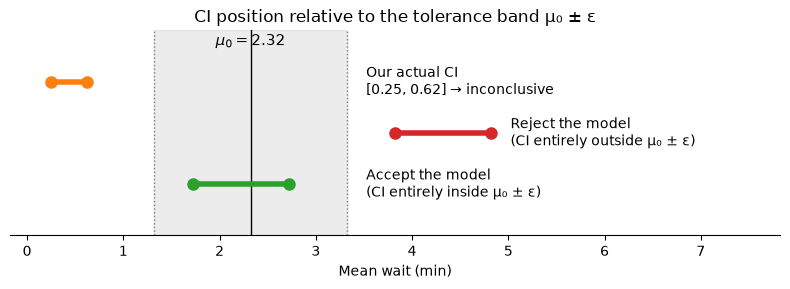

: 

In [ ]:
# Visual confirmation: three scenarios with our actual CI as the inconclusive case
import matplotlib.pyplot as plt

scenarios = [
    ('Accept the model\n(CI entirely inside μ₀ ± ε)',  (mu0 - 0.6, mu0 + 0.4),  '#2ca02c'),
    ('Reject the model\n(CI entirely outside μ₀ ± ε)', (mu0 + 1.5, mu0 + 2.5),  '#d62728'),
    (f'Our actual CI\n[{L:.2f}, {U:.2f}] → inconclusive', (L, U),               '#ff7f0e'),
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.axvspan(mu0 - eps, mu0 + eps, color='gray', alpha=0.15, label=f'tolerance μ₀ ± ε  (ε = {eps})')
ax.axvline(mu0 - eps, color='gray', linestyle=':', linewidth=1)
ax.axvline(mu0 + eps, color='gray', linestyle=':', linewidth=1)
ax.axvline(mu0,       color='black', linewidth=1)
ax.text(mu0, 2.7, f'$\\mu_0 = {mu0:.2f}$', ha='center', fontsize=11)

for k, (label, (Lk, Uk), color) in enumerate(scenarios):
    ax.hlines(k, Lk, Uk, color=color, linewidth=4)
    ax.plot([Lk, Uk], [k, k], 'o', color=color, markersize=8)
    ax.text(max(Uk, mu0 + eps) + 0.2, k, label, fontsize=10, va='center')

ax.set_xlim(mu0 - 2.5, mu0 + 5.5); ax.set_ylim(-1, 3)
ax.set_xlabel('Mean wait (min)')
ax.set_yticks([])
for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
ax.set_title('CI position relative to the tolerance band μ₀ ± ε')
plt.tight_layout(); plt.show()

# Caveat — when the CI is "inconclusive"

The natural reaction is to add more replications and recompute the CI — **but this is statistically unsound**. Deciding *after the fact* to collect more data and re-test inflates the $\alpha$-error (*optional stopping*).

**Clean procedure instead:**

1. Treat the existing replications as a **pilot** — use them only to estimate $\sigma$.
2. Use that estimate in the power formula to compute the required sample size $n$ for your tolerance $\varepsilon$.
3. Start a **fresh** study with $n$ independent replications.
4. Evaluate it **once** and report the verdict.

Appending data to the same analysis is *not* the same as running a new study — even though it looks similar.

# Variant — using historical *input* data, not just historical *output*

So far we fed the model **fitted distributions** (Exponential arrivals/services) and compared its outputs to historical outputs. There is a stronger variant: feed the model the **actual observed inputs** from history, and compare its outputs to the real outputs *event by event*.

**Idea:** if the real system experienced specific arrival times $t_1, t_2, \ldots$ and specific service durations $s_1, s_2, \ldots$ on a given day, *replay* those exact events through the model. Any remaining gap between model-output and real-output is then attributable to **structural assumptions**, not to randomness in the inputs.

Conceptually, this aligns the model and the real system on the **same noise sequence** — the same idea behind variance-reduction techniques used when comparing alternative simulation designs (a topic of the upcoming *Analysis of Multiple Systems* lecture).

# Historical-input replay — what it tells us

When we feed the model the *exact* observed arrivals and service durations, the wait times match the real system **per student**, up to numerical noise. This is the strongest possible validation evidence: with no input randomness left to explain differences, any remaining gap reveals a **structural mismatch** in the model.

**When this technique is appropriate:**
- We have detailed event-level historical data, not just summary statistics.
- The model's structure should reproduce reality exactly when given correct inputs.

**Limitations:**
- Tells us nothing about how the model behaves with *new* inputs — that's what the standard I/O test (with fitted distributions) checks.
- In practice, both techniques are complementary: replay-with-history catches structural bugs; standard I/O test checks generalization.

---
# What if there is no real system?

# Validating without a real system

Sometimes we simulate systems that **do not yet exist** (a new factory layout, a redesigned ER) — there's no historical output to compare against. Two options:

1. **Turing test** — let an expert see the model output mixed with output from similar real systems and judge
2. **Transfer of confidence** — validate the model against a *similar* existing system, then argue the validation transfers

Both are weaker than direct input-output validation but better than nothing.

# Turing test in simulation

Show an expert 10 "performance reports" — 5 from the real system, 5 from the simulation — without telling them which is which.

- If the expert can **reliably distinguish** real from simulated → they can probably tell us **what's wrong** with the model. Interview them.
- If they **cannot distinguish** → the test gives *no evidence of model inadequacy*.

*Note*: "no evidence of inadequacy" is **not** "evidence of adequacy" — same logic as a goodness-of-fit test that fails to reject.

# Transfer of confidence — when does it apply?

If we validated a model of system A and want to use a *related* model for system B:

**Transfer is reasonable** when changes between A and B are:

- minor numerical parameter changes (e.g. arrival rate ±20%)
- minor distributional changes (e.g. service times shift from Exponential to Lognormal with similar moments)

**Transfer is *not* reasonable** when changes involve:

- a change in queue discipline (FCFS → priority)
- a different design for the new system (one queue → many queues)
- substantially different operational logic

Alternative: **partial input-output validation** — validate sub-systems of the new model against existing analogues.

# Recap

<br>

| Topic | Key idea |
|---|---|
| Verification vs. validation | *Building the model correctly* vs *building the correct model* |
| Verification techniques | Trace · sanity check · analytical comparison · debugger · documentation |
| Validation framework | (1) Face validity → (2) Validate assumptions → (3) Input-output test |
| Input-output test | Compare model replications to historical data (t-test or CI) |
| Type I / II / power | Failing to reject ≠ proving the model is right |
| No real system? | Turing test · transfer of confidence · partial validation |

**Take-away:** *V&V is iterative, mostly informal, and never fully "done" — but every cycle increases the model's credibility.*

# 🧠 Mentimeter — your turn

➡️ Open the Mentimeter and answer the question on screen.

# Next session

**Output Analysis** — now that we trust the model, how do we extract trustworthy *conclusions* from its output?

- Each simulation run is one sample from a distribution of possible runs
- Confidence intervals via independent replications
- Warm-up period; terminating vs steady-state simulations

*This is where simulation becomes statistical inference.*

---
# Appendix

# Theoretical results — finite-capacity (blocking) systems

When the waiting room is limited, arrivals that find the system full are **blocked** and lost.

## M/M/1/K — single server, capacity $K$

Steady-state distribution (for $\rho \neq 1$):

$$P_n = \frac{1-\rho}{1-\rho^{K+1}} \, \rho^n, \quad n = 0, 1, \ldots, K$$

**Blocking probability** (probability a new arrival is turned away):

$$P_{\text{block}} = P_K = \frac{(1-\rho)\,\rho^K}{1-\rho^{K+1}}$$

**Effective arrival rate** (the rate at which customers actually enter):

$$\lambda_{\text{eff}} = \lambda \, (1 - P_{\text{block}})$$

Mean number in system $L$ and mean queue length $L_q$ follow from $P_n$. Note: $\rho > 1$ is allowed here — the queue can never explode because $K$ caps it.

## M/M/c/c — Erlang loss (no waiting room)

Classical telephony model: $c$ parallel servers, **no queue**. Blocked calls leave immediately. With offered load $a = \lambda / \mu$ (in *Erlangs*):

$$P_{\text{block}} = B(c, a) = \frac{a^c / c!}{\sum_{k=0}^{c} a^k / k!}$$

(The famous **Erlang B formula**, used to size telephone exchanges and call centres.)

**Verification benefit:** if your simulation has a finite buffer or loses customers, you can compare the simulated blocking rate against $P_K$ (M/M/1/K) or $B(c, a)$ (Erlang B). A persistent discrepancy reveals an implementation drift that $W_q$ alone might not detect.

# Appendix — Relationship between t-test and CI testing

*Optional reading — for interested students only.*

Both procedures rest on the same statistical machinery: the standard error of the mean and the resulting CI / test-statistic distribution.

**They differ only in *where* the substantive tolerance parameter enters the procedure:**

| | t-test | CI testing |
|---|---|---|
| Tolerance parameter | $\delta_{\text{tol}}$ | $\varepsilon$ — *conceptually the same* |
| Where the parameter is used | At **study design** (to compute $n$) | At **evaluation** (in the decision rule) |
| What is tested | $H_0$: no bias | CI position relative to the tolerance band |
| Verdict | Reject / Fail to reject | Accept / Reject / Inconclusive |

**Practical consequence:**

When you use the same tolerance value ($\delta_{\text{tol}} = \varepsilon$) and the same sample size for both procedures, you typically end up with the same decision. The two methods are not two different answers — they are the same answer in two different languages.

CI testing also allows ex-ante sample size determination, with a formula very similar to the t-test power formula:

$$n_{\text{CI}} \;\approx\; \left(\frac{z_{1-\alpha/2} + z_{1-\beta/2}}{\varepsilon} \cdot s\right)^{\!2}$$

(the only difference from the t-test formula is $z_{1-\beta/2}$ instead of $z_{1-\beta}$ — the stricter requirement that *both* CI endpoints must lie inside the tolerance band).

# Appendix — TOST (Two One-Sided Tests)

*Optional reading — for interested students only.*

The formal **hypothesis-test variant** of CI testing is called **TOST** (Two One-Sided Tests). It tests:

$$H_0: \mu_{\text{model}} \notin [\mu_0 - \varepsilon, \, \mu_0 + \varepsilon] \quad\text{vs.}\quad H_1: \mu_{\text{model}} \in [\mu_0 - \varepsilon, \, \mu_0 + \varepsilon]$$

Unlike the classical t-test, here the *acceptance claim* is the alternative hypothesis — we aim to gather evidence *in favour* of equivalence, rather than evidence against the null of "no bias".

TOST works by running two one-sided t-tests:

1. Test 1: $H_0^{(1)}: \mu \leq \mu_0 - \varepsilon$ (lower tolerance)
2. Test 2: $H_0^{(2)}: \mu \geq \mu_0 + \varepsilon$ (upper tolerance)

Both at significance level $\alpha$. If **both** $H_0$ hypotheses are rejected, the model is considered **equivalent** (within tolerance).

**Practical relevance:**

- TOST is the standard for **bioequivalence studies** in pharmaceuticals ("Is the generic drug equivalent to the original?").
- Has a well-developed sample-size literature — the formulas largely match what we showed above for CI testing.
- Allows a *formal* statistical statement of model acceptance, instead of just "no evidence of bias found".